In [1]:
# 

In [1]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine


Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=17892 sha256=d00d1defccce7a647b9c4cc335a5ed4fb7a4f96f1478d5aca4fd7ffeff880eff
  Stored in directory: /tmp/pip-ephem-wheel-cache-86t_6_yb/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [2]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr

#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns


In [6]:
import fwiVis.fwiVis as fv

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Final_dataset_as_of_20240209.csv"
#fire3 = fv.prep_fire_files(path)

path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire3 = fv.prep_fire_files(path)
fire_first = fire3

fire_export = fire3
fire_export = fire_export.to_crs("4326")
fire_export["lon_centroid"] = fire_export["geometry"].centroid.x
fire_export["lat_centroid"] = fire_export["geometry"].centroid.y
fire_export.to_csv(f"{os.path.abspath("data")}/with_lat_lon_Quebec_v3_full_data_perimeters20241112.csv")

#ciffc = pd.read_csv("/projects/old_shared/fire_weather_vis/Lightning_analysis/CIFFC_data/ciffc_all_canada.csv")
ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
ciffc = ciffc[ciffc.field_agency_code == "qc"]

ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")

ciffc["geometry_point"] = ciffc.geometry

/tmp/ipykernel_1216/3102677776.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/tmp/ipykernel_1216/3102677776.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [5]:
fire3 = fire3.sort_values(by = ["fireID", "t"])

fire3 = fire3[~fire3.FWI.isna()]
# df = fire3[fire3.fireID == '2367']
# df


In [6]:

def corrected_farea_diff(df, var = "farea"):
    #sub_df = df[]
    df[f"{var}_diff"] = df[var].diff()
    min_t = df.t.min()
    if(np.isnan(*df.loc[df.t == min_t, [f"{var}_diff"]].values)):
        df.loc[df.t == min_t, [f"{var}_diff"]] = df.loc[df.t == min_t, [f"{var}"]].values
    else:
        print("Error! First value not NaN")
        df = None
    return(df)

def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df["is_ig"] = False
    df.loc[df.t == df.t.min(), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)


fire3 = fire3[~fire3.FWI.isna()]

post_fr = fire3

post_fr = post_fr.groupby("fireID").apply(extinction).reset_index(drop = True)
post_fr = post_fr.groupby("fireID").apply(just_the_igs).reset_index(drop = True)

fire3 = fire3.groupby("fireID").apply(corrected_farea_diff).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(just_the_igs).reset_index(drop = True)
#fire3.farea = fire3.farea.astype("int64")
fire3 = fire3.sjoin(ciffc)

row_mask = (~fire3.fireID.str.contains("_"))

#fire3[row_mask].hvplot.scatter(x='FWI', y='farea_diff', hover_cols=['fireID', 't'])
#fire3[row_mask].plot.scatter(x='FWI', y='farea_diff')

/tmp/ipykernel_1149/127325034.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_1149/127325034.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_1149/127325034.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `

In [7]:
supression = fire3.groupby("fireID").field_response_type.unique().reset_index()
supression

supression["len"] = supression.field_response_type.apply(len)

multi_suppress_ids = supression[supression.len> 1].fireID

supression[supression.len> 1]
fire_ids_not_unique_supression = supression[supression.len> 1].fireID

In [8]:
### Function that takes a point and looks for the multi polygons that intersect with that point. 
#It then assignes just the polygon portion of the multipolygon with the point's ID. 
# At the end, I want to put in an ID where there are two supression stratagies, and I want to get two IDs out, one per supression stratagy: subset to just the portion where there is one supression strategy.  
# I have found one fire so far (1082) where this wont work, because at least some probable fire that could/should be tied to one surpession strategy doesn't overlap with the point, even after the reported time, and by the time out polygon overlapped with the point it was already merged with anouther one. So boo. 

import shapely
import shapely.geometry as gmt
from shapely.geometry import MultiPolygon, Point, Polygon

def split_multipolygon(multipolygon, point):
    """Splits a MultiPolygon into separate polygons based on intersection with a point.

    Args:
        multipolygon (MultiPolygon): The MultiPolygon to split.
        point (Point): The point used to determine intersection.

    Returns:
        list: A list of individual polygons.
    """

    polygons = []
    for polygon in multipolygon:
        if polygon.intersects(point):
            polygons.append(polygon)
    return polygons


def exactly_one_true(lst):
    """Checks if exactly one element in the list is True."""
    return sum(lst) == 1

def sep_supression(fid, df1,  meter_crs = 3571, point_crs = 4326): #df2,
    print("Assuming df1 is in  crs 4326, and df2 is in a metered crs (35")
    df = df1[df1.fireID == fid]
    #df2 = df2[df2.fireID == fid]
    #df = df[30:40]
    # df = df.to_crs(meter_crs)
    # df.geometry = df.geometry.buffer(500) ## 200 meeters
    # df = df.to_crs(point_crs)
    ciffc_resp = df.field_response_type.unique()
    resp_l = []
    #for r in ciffc_resp:
    just_intersect = []
    #unique_points = df[["field_latitude", "field_longitude", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True) # (df.field_response_type == r)
    #unique_points = gpd.GeoDataFrame(unique_points, geometry= gpd.points_from_xy(unique_points.field_longitude, unique_points.field_latitude,  crs = 4326))

    unique_points = df[["geometry_point", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True)
    unique_points = gpd.GeoDataFrame(unique_points, geometry= unique_points.geometry_point,  crs = 3571)
    #return(unique_points)
    #points = [Point(lon, lat) for lon, lat in zip(unique_points.field_longitude, unique_points.field_latitude)]
    points = unique_points.geometry_point
    #print(len(points))
    #return(points)
    
    for index, row in df.iterrows(): # [df.field_response_type == r]
    #if isinstance(row['geometry'], MultiPolygon):
        #print("This is a multipolygon")
       #split_polygons = split_multipolygon(row['geometry'], intersection_point)
        ## Double check that only 1 point intersects with polygon. 
        if(isinstance(row['geometry'], Polygon)):
            row['geometry'] = gmt.MultiPolygon([row['geometry']])
        for polygon in row['geometry'].geoms:
            #print(shapely.intersects(points, polygon))
            unique_points["Does_it_intersect"] = np.nan
            intersecting_points = []
            for point in points:
                intersecting_points.append(polygon.intersects(point))
                    
            unique_points["Does_it_intersect"] = intersecting_points
            up_group = unique_points.groupby("field_response_type").Does_it_intersect.unique().reset_index()
            #return(up_group)

            only_one_type_of_supression_intersects = (sum(up_group.Does_it_intersect.explode().values) == 1)
            #intersecting_points = [point for point in points if polygon.intersects(point)]
            #print(intersecting_points)

            #if len(intersecting_points) == 1:  # Exactly one point intersects
            if only_one_type_of_supression_intersects: ### Only one catagory intersects with this polygon
                #print(only_one_type_of_supression_intersects)
                #return(up_group)
                new_row = row.copy()
                new_row["geometry"] = polygon
                new_row["farea"] = (polygon.area / (1000 * 1000))
                new_row["fperim"] = np.nan
                new_row["meanFRP"] = np.nan
                
                
                
                # try:
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.sum()].field_response_type.iloc[0])# tmp2[tmp2.source.explode()].degree.iloc[0]
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0]) + "." + str(*unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.unique())
                sup = str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0])
                new_row["fireID"] = str(fid) + "." + sup +"." +  ".".join(unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.astype("str"))
                new_row["field_response_type"] = sup
                    
                # except:
                #     return(unique_points)
                # #     return(up_group)
                    
                just_intersect.append(new_row)
                # fig, ax = plt.subplots(figsize=(8, 6))
                # #print(type(new_row))
                # #new_row.plot(color = "green")
                # plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.show()
            else:
                new_row = row.copy()
                new_row["geometry"] = polygon
                # fig, ax = plt.subplots(figsize=(8, 6))
                # plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.show()
                #print("skipping")
                #just_intersect.append(None)
    # else:
    #     just_intersect.append(row)
    just_intersect_df = gpd.GeoDataFrame(just_intersect)
    just_intersect_df = gpd.GeoDataFrame(just_intersect_df, geometry = just_intersect_df.geometry, crs = 3571)
    #just_intersect_df = just_intersect_df[just_intersect_df.field_response_type == sup] # Dropping false lable
    just_intersect_df = just_intersect_df.drop_duplicates()
    # if(len(just_intersect_df) > 0):
    #     #print(just_intersect)
    #     just_intersect_df.fireID = just_intersect_df.fireID.astype("str") + "." + r
    #     #print(just_intersect_df)
    #     resp_l.append(just_intersect_df)
    # else:
    #     print(f"{fid} had no independant multi-polygons to split")
#full_df = pd.concat(resp_l, axis=0)
    return(just_intersect_df)
    

def check_that_continious_record(df):
    min_t = df.t.min()
    max_t = df.t.max()
    #dates = pd.date_range(start= min_t, end=  max_t).to_pydatetime().tolist()
    dates = pd.date_range(start= min_t, end=  max_t).strftime('%Y-%m-%d 12:00:00').tolist()
    len_df = len(df.t.unique())
    #print(df.t.unique())
    len_seq = len(dates)
    #print(dates)
    if(len_df != len_seq):
        print(f"FireID {df.fireID.unique()} is not a continious sequence.")
        return(False)
    d_list = []
    for d in dates:
        some_dates = df[df.t == d]
        d_list.append(len(some_dates) > 0)
    return(any(d_list))

In [9]:
### remake IDs with duel supression status 


skip_list = ["1082", 
            "1324"] ### has more than one supression, but seems like the reported point doesn't overlap with an indepandant multipolygon. 

duel_sup =  [item for item in fire_ids_not_unique_supression if item not in skip_list]
dfs = []
for s in duel_sup:
    print(s)
    tmp = sep_supression(str(s), fire3)
    dfs.append(tmp)
foo = pd.concat(dfs)

foo = gpd.GeoDataFrame(foo, geometry = foo.geometry, crs = 3571)
#foo = foo.set_crs(4326)


#### Check that there is a continious t 


bools = foo.groupby("fireID").apply(check_that_continious_record)
print(f"Are all the fires continuios records???: {all(bools)}")

if(all(bools)):
    fire3 = fire3[~fire3.fireID.isin(fire_ids_not_unique_supression)]
    foo = foo.to_crs(fire3.crs)
    fire3 = pd.concat([fire3, foo], ignore_index=True)

1088
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
226
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2545
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2647
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2649
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
Are all the fires continuios records???: True


/tmp/ipykernel_1149/919185589.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [10]:
def chop_fires_at_end(df):
    final_t = df[df.n_newpixels > 0].t.max()
    df = df[df.t <= final_t]
    return(df)

#post_fr = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)


fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]

/tmp/ipykernel_1149/455317430.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [11]:
#fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()
#fire3 = fire3.groupby("fireID").apply(corrected_farea_diff)
fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(3).max().reset_index(drop = True)
fire3["FWI_diff"] = fire3.groupby("fireID").FWI.diff()

fire3["farea_diff_stand"] = fire3.groupby("fireID").farea.diff()



## Fireline 
fire3["flinelen_shifted"] = fire3.groupby("fireID").flinelen.shift(periods = 1)
fire3["fperim_shifted"] = fire3.groupby("fireID").fperim.shift(periods = 1)
fire3["flinelen_diff"] = fire3.groupby("fireID").flinelen.diff()
fire3["fperim_diff"] = fire3.groupby("fireID").fperim.diff()


### Some useful vars to color by 
def assign_day_of_fire(df):
    df = df.sort_values(by = "t")
    df['day_of_fire'] = df.t.rank()
    #df['day_of_fire'] = df['day_of_fire'].astype("int64")
    return(df)


def get_max_duration(df):
    max_duration = df.duration.max()
    df["max_duration"] = max_duration


# fire3 = fire3.groupby("fireID").apply(assign_day_of_fire).reset_index(drop = True)
# fire3["farea_shifted"] = fire3.groupby("fireID").farea.shift(periods = 1)

# fire3["normalized_farea_diff"] = fire3.farea_diff/fire3.farea_shifted



fire3["GEOS_IMERGEARLY"] = fire3["GEOS-5.IMERGEARLY"]

def line_trend(data):
    # df = df.sort_values(by = "t")
    # df["time_delta"] = df.t.astype("datetime64[ns]") - df.t.astype("datetime64[ns]").min()
    
    # df["t_float"] = df["time_delta"].dt.days

    seq = range(0, (len(data)), 1) ##  Create an even sequence to represent FWI in time. 
    z = np.polyfit(seq, data, 1)
    #df[f"line_trend_{var}"] = z[0] ## Slope of trend line
    return(z[0])


In [12]:

### Implementing FBP technical handbook equation 88 https://drive.google.com/file/d/1xBseasON22KFC4jEVBKk75EOuUK-dpM2/view

#1) Calculate the length and breadth of the fires. Simple way, get just the convex hull and the longer one is length. More complex, length shoudl maybe be tied to where active fire line is (to represent head fire?)
from shapely.geometry import LineString

def get_length_to_breadth(polygon):
    
    mbr_points = list(zip(*polygon.minimum_rotated_rectangle.exterior.coords.xy)) ### oh no projection issues? 
    # calculate the length of each side of the minimum bounding rectangle
    mbr_lengths = [LineString((mbr_points[i], mbr_points[i+1])).length for i in range(len(mbr_points) - 1)]

    # get major/minor axis measurements
    minor_axis = min(mbr_lengths)
    major_axis = max(mbr_lengths)
    
    return(major_axis/minor_axis)



fire3["LB"] = fire3.geometry.apply(get_length_to_breadth)


## Calculate spread rate

row_mask = (fire3.fperim_diff > 0.1) & (fire3.flinelen > 0)
perimeter_growth_rate = fire3[row_mask]["fperim_diff"] ### Modify by length of active fire line? 
LB = fire3[row_mask]["LB"]

def get_perimeter_growth_rate(df):
    term_a = ((1/df["LB"]) + 1) # will this vectorize? 
    term_b =  1 + (((df["LB"] - 1) / (2 * (df["LB"] + 1)))**2)

    df["tot_ros_all_perim"] = 2 * (df["fperim_diff"] / (term_a * term_b)) ### Will have same units as perimeter growth in m/ 24 hour. Not area. 
    df["tot_ros_flinelen_shifted"] = 2 * (df["flinelen_shifted"] / (term_a * term_b)) ### Will have same units as perimeter growth in m/ 24 hour. Not area. 
    return(df)



fire3 = fire3.groupby("fireID").apply(get_perimeter_growth_rate).reset_index(drop = True)

# fire3["spread_rate"] = np.nan
# fire3.loc[row_mask, "spread_rate"] = 1/(2*((np.pi * (1+(1/LB)) * (1 + ((LB -1)/(2*(LB+1)))**2)) / perimeter_growth_rate ))


# fire3["flinelen_rolling"]  = fire3.groupby("fireID").flinelen.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["flinelen_diff_rolling"] = fire3.groupby("fireID").flinelen_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["fperim_rolling"] = fire3.groupby("fireID").fperim.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["fperim_diff_rolling"] = fire3.groupby("fireID").fperim_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["spread_rate_rolling"] = fire3.groupby("fireID").spread_rate.rolling(rolling_num).agg(agg_function).reset_index(drop = True)


# long_fires = fire3[fire3.day_of_fire > 3].fireID.unique()
# #fire3['max_dof'] = fire3.groupby("fireID").day_of_fire.max()

# row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

/tmp/ipykernel_1149/2227942284.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [13]:
y_vals = ["farea_diff", "farea_diff_stand", "flinelen", "flinelen_diff", 'tot_ros_all_perim', 'tot_ros_flinelen_shifted']
rolling_nums = [3, 7]
agg_functions = ["mean", "max", line_trend] ## Need to do line_trend seperately. 
#agg_function = "max" # max


def str_fix(string):
    try:
        fin_str = string.__name__
    except:
        fin_str = string
    return(str(fin_str))

fire3 = fire3.sort_values(by = ["fireID", "t"]) ## Needs t to be sorted for trend line calculation
x_rolling = ["GEOS_IMERGEARLY", "FWI"]
x_rolling2 = x_rolling.copy()
y_vals1 = y_vals.copy()
for rolling_num in rolling_nums:
    
    for xr in x_rolling:
        # var_name_tmp = f"{xr}_rolling_{rolling_num}_line_trend"
        # fire3[var_name_tmp] = fire3.groupby("fireID").rolling(rolling_num).agg(line_trend, var = xr).reset_index(drop = True)
        # x_rolling2.append(var_name_tmp)
        for agg_function in agg_functions:
            var_name_tmp = f"{xr}_rolling_{rolling_num}_{str_fix(agg_function)}"
            fire3.loc[:, [var_name_tmp]] = fire3.groupby("fireID")[xr].rolling(rolling_num).agg(agg_function).reset_index(drop = True)
            x_rolling2.append(var_name_tmp)
    for yv in y_vals:
        for agg_function in agg_functions:
            var_name_tmp = f"{yv}_rolling_{rolling_num}_{str_fix(agg_function)}"
            fire3.loc[:, [var_name_tmp]] = fire3.groupby("fireID")[yv].rolling(rolling_num).agg(agg_function).reset_index(drop = True)
            y_vals1.append(var_name_tmp)

# fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["FWI_diff_rolling"] = fire3.groupby("fireID").FWI_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3['farea_rolling'] = fire3.groupby("fireID").farea.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3['farea_diff_rolling'] = fire3.groupby("fireID").farea_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["GEOS-5.IMERGEARLY_rolling"] = fire3.groupby("fireID")["GEOS-5.IMERGEARLY"].rolling(rolling_num).agg(agg_function).reset_index(drop = True)

#long_fires = fire3[fire3.day_of_fire > 3].fireID.unique()
#fire3['max_dof'] = fire3.groupby("fireID").day_of_fire.max()

#row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

In [14]:
# row_mask = (fire3.fperim_diff > 0.1)

# plt.scatter( fire3[row_mask]['GEOS-5.IMERGEARLY'], fire3[row_mask].tot_ros_all_perim)

In [15]:
# row_mask = (fire3.fperim_diff > 0.1)

# plt.scatter( fire3[row_mask]['GEOS-5.IMERGEARLY'], np.log(fire3[row_mask].tot_ros_flinelen_shifted))
# plt.show()

# plt.scatter( fire3[row_mask]['GEOS-5.IMERGEARLY'], fire3[row_mask].tot_ros_flinelen_shifted)
# plt.show()

In [16]:
# plt.scatter( fire3.farea, fire3.farea_diff)
# plt.show()

In [17]:
# plt.scatter( fire3.farea, fire3.flinelen)
# plt.show()

In [18]:
# plt.scatter( x = fire3.farea_diff, y = fire3.flinelen)
# plt.show()

In [19]:
# row_mask = (fire3.farea_diff > 0.4)

# from math import sqrt
# def mod_list(old):
#     return [x/(1.5) for x in old]

# seq = list(range( 0, round(fire3[row_mask].farea_diff.max()), round(fire3[row_mask].farea_diff.max()/ len(fire3[row_mask].farea_diff))))
# plt.scatter( x = fire3[row_mask].farea_diff, y = fire3[row_mask].flinelen)
# plt.plot(seq, mod_list(seq))
# plt.xlabel("Fire Area Growth Km^2")
# plt.ylabel("Active Fire Line Km")
# plt.show()

In [20]:

# seq = list(range( 0, round(fire3[row_mask].farea_diff.max()), round(fire3[row_mask].farea_diff.max()/ len(fire3[row_mask].farea_diff))))
# plt.scatter( x = fire3[row_mask].farea_diff, y = fire3[row_mask].flinelen_shifted)
# plt.plot(seq, mod_list(seq))
# plt.xlabel("Fire Area Growth Km^2")
# plt.ylabel("Active Fire Line of previous fire")
# plt.show()

In [21]:
# ### Check how the perimeter transforms into area

# plt.scatter( x = fire3[row_mask].farea_diff, y = fire3[row_mask].flinelen_shifted)
# plt.plot(seq, mod_list(seq))
# plt.xlabel("Fire Area Growth Km^2")
# plt.ylabel("Active Fire Line of previous fire")
# plt.show()

In [22]:



# plt.scatter( x = fire3['GEOS-5.IMERGEARLY'], y = fire3.flinelen_shifted/fire3.fperim_shifted)
# plt.xlabel("FWI")
# plt.ylabel("Active Fire Line of Previous Day")
# plt.show()

In [23]:
# plt.scatter( x = fire3['GEOS-5.IMERGEARLY'], y = fire3.flinelen)
# plt.xlabel("Fire Area Growth Km^2")
# plt.ylabel("Active Fire Line of previous fire")
# plt.show()

In [24]:

# plt.scatter( x = fire3['GEOS-5.IMERGEARLY'] * (fire3.flinelen_shifted/fire3.fperim_shifted), y = fire3.farea_diff)
# plt.xlabel("FWI * active fire line")
# plt.ylabel("Fire Growth")
# plt.show()

In [25]:
# plt.scatter( x = fire3[fire3.farea_diff > 0.1]['GEOS-5.IMERGEARLY'], y = (fire3[fire3.farea_diff > 0.1].farea_diff) ** (1/2))
# plt.xlabel("FWI * active fire line")
# plt.ylabel("Fire Growth")
# plt.show()

In [26]:
# plt.scatter( x = fire3['GEOS-5.IMERGEARLY'], y = fire3.farea_diff_stand)
# plt.xlabel("FWI * active fire line")
# plt.ylabel("Fire Growth")
# plt.show()

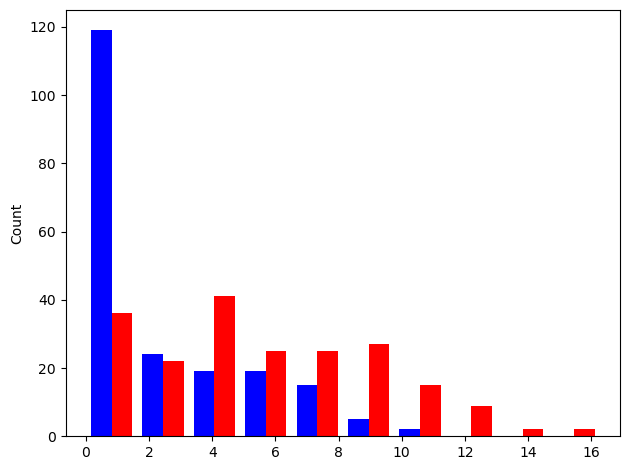

N of 203 from extinquishing fires.
N of 204 from ignighting fires.


In [27]:
### Looking at just the post-fire vs ignition FWI

colors = ['b','r']
labels = ["FWI After Fire Stopped", "FWI When Fire Started"]
alphas = [0.3, 0.3]

fig, ax1 = plt.subplots()
ax1.hist([post_fr[post_fr.is_ext == True]['GEOS-5.IMERGEARLY'],post_fr[post_fr.is_ig == True]['GEOS-5.IMERGEARLY']],color=colors, label = labels)
#ax1.set_xlim(-10,10)
ax1.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"N of {len(post_fr[post_fr.is_ext == True]['GEOS-5.IMERGEARLY'])} from extinquishing fires.")
print(f"N of {len(post_fr[post_fr.is_ig == True]['GEOS-5.IMERGEARLY'])} from ignighting fires.")

N of 203 from extinquishing fires.
N of 204 from ignighting fires.


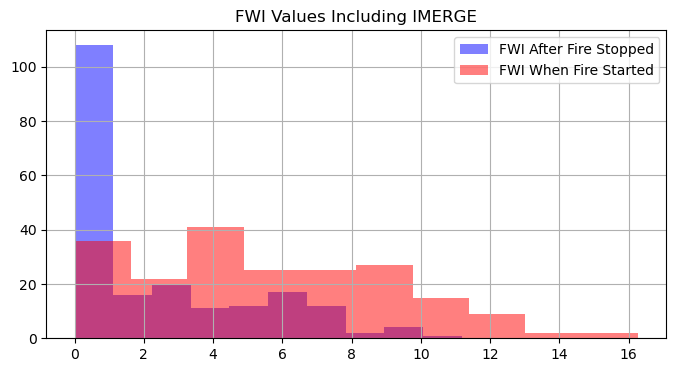

In [28]:
post_fr[post_fr.is_ext == True]['GEOS-5.IMERGEARLY'].hist(color = "blue", alpha = 0.5, label = "FWI After Fire Stopped")
post_fr[post_fr.is_ig == True]['GEOS-5.IMERGEARLY'].hist(figsize=(8, 4), color = "red", alpha = 0.5, label = "FWI When Fire Started")

print(f"N of {len(post_fr[post_fr.is_ext == True])} from extinquishing fires.")
print(f"N of {len(post_fr[post_fr.is_ig == True])} from ignighting fires.")
plt.legend()
plt.title("FWI Values Including IMERGE")

# Display the plot    
plt.savefig(os.path.abspath("exploratory_figs/igs_vs_ext_hist_geos5.png"))
plt.show()

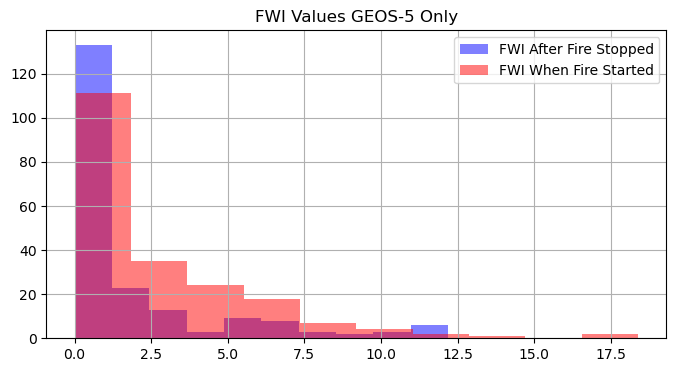

In [29]:
  
post_fr[post_fr.is_ext == True]['FWI'].hist(color = "blue", alpha = 0.5, label = "FWI After Fire Stopped")
post_fr[post_fr.is_ig == True]['FWI'].hist(figsize=(8, 4), color = "red", alpha = 0.5, label = "FWI When Fire Started")
plt.legend()
plt.title("FWI Values GEOS-5 Only")
# Display the plot    
plt.savefig(os.path.abspath("exploratory_figs/igs_vs_ext_hist_IMERGE.png"))
plt.show()

## Data prepereation steps
- chop of fires at end
- create all varaibles
- merge with CIFFC



## Aspects of fires to relate to FWI

- farea_diff_stand (standard)
- farea_diff (corrected - first observation is included)
- flinelen - length of the active fireline
- eliisoid equations based on perimeter growth
- ellipsoid equations based on active fire line
- active fireline as a fracton of perimeter growth


## Data translformations to fire aspects

- square-root
- lagged
- logged
- square-root + lagged
- logged + lagged
- rolling (?) -- leave off?
   - diff rolling functions
   - mean
   - max and then drop non-uqnique vals
   - mean of previous 3 days
   - mean (7 days)
   - trend from last 3 (4?) days (increasing or decreasing)


## FWI data transforms

- anticedent conditions mean ------ mean rolling?
- mean of X days before a given spread
- logit model of grow/not grow FWI


## How test? 
- heteroskedasticity-friendly metric of performence (Spearmans's)
- Run them all, in a tiered way.
- Include figures that show all the corrections. / transformations. 
- 
- 

In [30]:
from scipy import stats
from patsy import ModelDesc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

def joint_plot(fire_delta, x, y):
        # plt.scatter(small_fire.FWI, (small_fire[f"fwi_error_{i}"] * small_fire[f"fwi_error_{i}"])**(1/2))
    #fire_delta[y] = fire_delta[y].astype("int")
    #fire_delta = fire_delta[[x, y]].dropna()
    fire_delta = fire_delta[[x, y]].drop_duplicates()

    formula = f"{y} ~ {x}"
    links = "Identity"
    #links = "Log"
    #families = "NegativeBinomial"
    
    families = "Gaussian"
    link_g = getattr(sm.genmod.families.links, links)
    method = getattr(sm.families, families)
    fire_delta = fire_delta[[x , y]].dropna()
    model = smf.glm(formula, data=fire_delta, family=method(link = link_g(), check_link=True)).fit()
    
    sns.jointplot(data=fire_delta, x= x, y=y, marker="+",  dropna = True, marginal_kws = {"bins": 20}) #  marginal_kws = {"log_scale": True} 
    #t.ax_marg_y.set_yscale("log")
    max_of_max = round(max(fire_delta[x].max(), fire_delta[y].max()))
    min_of_min = round(min(fire_delta[x].min(), fire_delta[y].min()))
    fire_delta['fitted'] = model.fittedvalues
    fire_delta['residuals'] = model.resid_response
    fire_delta = fire_delta.sort_values(by = x)
    predictions = model.get_prediction(fire_delta, transform = True) #df, transform = False
    fire_delta['predicted'] = predictions.predicted_mean
    fire_delta['conf_int_low'], fire_delta['conf_int_high'] = predictions.conf_int().T
    plt.fill_between(fire_delta[x], fire_delta['conf_int_low'], fire_delta['conf_int_high'], alpha=0.2, color = "yellow")
    


    sns.lineplot(x=x, y='predicted', data=fire_delta, legend = False)
    #plt.plot(range(min_of_min, max_of_max), range(min_of_min, max_of_max), color = "black")
    #plt.xlabel(x)
    #plt.ylabel(y)
    
    ## Stats
    r_sq = 1 - (np.sum((fire_delta['residuals'])**(2)) / np.sum((fire_delta[y] - fire_delta[y].mean())**(2)))
    #bias = np.sum(fire_delta[y] - fire_delta[x] )/len(fire_delta[x])
    res = stats.spearmanr(fire_delta[x], fire_delta[y], nan_policy = 'omit')
    spear = res.statistic
    p_val_spear = res.pvalue
    plt.title("")
    #print("R^2 from modeled line: " + str(r_sq) )
    #print("Spearman Correlation: " + str(spear) )
    plt.savefig(f'{os.path.abspath("exploratory_figs")}/{y}_vs_{x}.png')
    #plt.show()
    plt.close()
    return([x, y, r_sq, spear, p_val_spear])

In [31]:
problem_vars = ['tot_ros_all_perim',  'tot_ros_flinelen_shifted']
lags = [-2, -1, 1, 2, 3]

for p in problem_vars:
    fire3[ fire3[p] < 0][p] = 0


y_vals2 = y_vals1.copy()

/srv/conda/envs/notebook/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [32]:
for v in y_vals:
    for i, l in enumerate(lags):
        lag_name = l
        if(l < 0):
            lag_name = "minus_" + str(np.absolute(l))
        var_name = f"{v}_shifted_{lag_name}"
        fire3[var_name] = fire3.groupby("fireID")[f"{v}"].shift(periods = l).reset_index(drop = True)
        y_vals2.append(var_name)

In [33]:
def example_transform(df, x, y):
    
    fig, ax1 = plt.subplots()
    df.loc[:, "t"] = df.t.astype('datetime64[ns]')
    df = df.sort_values(by = "t")
    
    # Plot the first dataset on the left y-axis
    ax1.plot(df["t"],  df[y], 'red')
    ax1.set_xlabel('')
    ax1.set_ylabel(f'{y}', color='red')
    ax1.tick_params(rotation=45)
    
    # Create a twin axes sharing the x-axis
    ax2 = ax1.twinx()
    
    # Plot the second dataset on the right y-axis
    ax2.plot(df["t"],  df[x], 'blue')
    ax2.set_ylabel(f'{x}', color='blue')

    # Show the plot
    plt.title(f'{df.fireID.unique()}')
    plt.savefig(f'{os.path.abspath("exploratory_figs")}/{df.fireID.unique()}_{y}_vs_{x}.png')
    plt.close()

In [34]:
 





# df_stats = {
#     "x":[None], 
#     "y": [None],
#     "r_sq": [None],
#     "spear": [None], 
#     "pval": [None]
# }
# stats_sum = pd.DataFrame(df_stats)
# x = 'GEOS_IMERGEARLY'

combinations = [(x, y) for x in x_rolling2 for y in y_vals2]

# demo_fire = fire3[fire3.fireID == '2729']

# today = datetime.today()

# for i, c in enumerate(combinations):
#     x = c[0]
#     y = c[1]
#     example_transform(demo_fire, x, y)
#     tmp = joint_plot(fire3, x,  y)
#     stats_sum.loc[i, "x"] = tmp[0]
#     stats_sum.loc[i, "y"] = tmp[1]
#     stats_sum.loc[i, "r_sq"] = tmp[2]
#     stats_sum.loc[i, "spear"] = tmp[3]
#     stats_sum.loc[i, "pval"] = tmp[4]
#     save_mod = i % 15
#     if(save_mod == 0):
#         stats_sum.to_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_{today.strftime("%Y-%m-%d")}.csv")
# stats_sum.to_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_{today.strftime("%Y-%m-%d")}.csv")

In [39]:
# ### Run if alreay partially done for loop above

demo_fire = fire3[fire3.fireID == '2729']
today = datetime.today()
# stats_sum = pd.read_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_2025-02-03.csv")

# combos_abridged = list(enumerate(combinations))
# combos_abridged = combos_abridged[len(stats_sum):]

# for i, c in combos_abridged:
#     x = c[0]
#     y = c[1]
#     example_transform(demo_fire, x, y)
#     tmp = joint_plot(fire3, x,  y)
#     stats_sum.loc[i, "x"] = tmp[0]
#     stats_sum.loc[i, "y"] = tmp[1]
#     stats_sum.loc[i, "r_sq"] = tmp[2]
#     stats_sum.loc[i, "spear"] = tmp[3]
#     stats_sum.loc[i, "pval"] = tmp[4]
#     save_mod = i % 15
#     if(save_mod == 0):
#         stats_sum.to_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_{today.strftime("%Y-%m-%d")}.csv")
# stats_sum.to_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_{today.strftime("%Y-%m-%d")}.csv")

In [36]:
fire3["farea_diff"] == fire3["farea_diff_stand"]

0       False
1        True
2       False
3        True
4        True
        ...  
4167     True
4168     True
4169     True
4170     True
4171     True
Length: 4172, dtype: bool

In [37]:
# # ### redo just a subset bc the perameter was generated incorrectly

# demo_fire = fire3[fire3.fireID == '2729']
# today = datetime.today()
# stats_sum = pd.read_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_2025-02-03.csv")

# # combos_abridged = list(enumerate(combinations))
# # combos_abridged = combos_abridged[len(stats_sum):]

# small = stats_sum[stats_sum.y.str.contains("farea_diff")]
# small_combos = zip(small.x, small.y)

# for i, c in zip(small.index, small_combos):
#     x = c[0]
#     y = c[1]
#     example_transform(demo_fire, x, y)
#     tmp = joint_plot(fire3, x,  y)
#     stats_sum.loc[i, "x"] = tmp[0]
#     stats_sum.loc[i, "y"] = tmp[1]
#     stats_sum.loc[i, "r_sq"] = tmp[2]
#     stats_sum.loc[i, "spear"] = tmp[3]
#     stats_sum.loc[i, "pval"] = tmp[4]
#     save_mod = i % 15
#     if(save_mod == 0):
#         stats_sum.to_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_{today.strftime("%Y-%m-%d")}.csv")
# stats_sum.to_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_{today.strftime("%Y-%m-%d")}.csv")

True
The largest spearman correlation is between: GEOS_IMERGEARLY_rolling_7_mean and farea_diff_rolling_3_mean at 0.6168379075027272,FWI_rolling_7_mean and farea_diff_rolling_3_mean at 0.6073012742180284, and GEOS_IMERGEARLY_rolling_7_mean and farea_diff_rolling_3_max at 0.6055601800274801


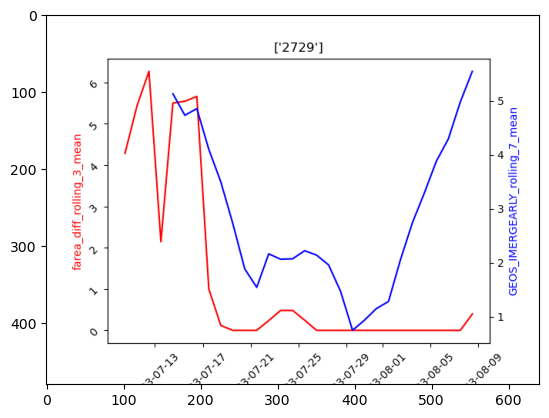

https://hub.openveda.cloud/user/mccabete/test_for_r/files/fwiVis/notebooks/exploratory_figs//home/jovyan/fwiVis/notebooks/exploratory_figs/['2729']_farea_diff_rolling_3_mean_vs_GEOS_IMERGEARLY_rolling_7_mean.png?_xsrf=MnwxOjB8MTA6MTczODY3NzE4N3w1Ol94c3JmfDEzMjpZMlJtWlRobE9EbGlOVFF5TkRWaU5XRXlZVGMzTW1Vd1ltTXhaalV4WVdFNlpETmhabUkzWVdJME16VmxPVGsyWmpWaVpqRTJOek16TVRSaFkyTm1aamswWldJMk1HWXdOak5oTmpsbU5EaG1NekE1WmpJMU1HTmtaR1poWXpsbFpnPT18YTI1ODE2MjY3ZTA0ZmY1N2I5NzI3NTY3NDRkOGRhYjIzNTQyOGMxNmQ2NjhlOWRlMmViYTFiY2U4MWY2ZDBjMw


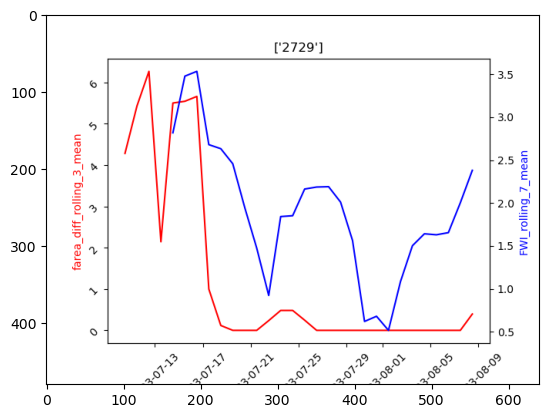

https://hub.openveda.cloud/user/mccabete/test_for_r/files/fwiVis/notebooks/exploratory_figs//home/jovyan/fwiVis/notebooks/exploratory_figs/['2729']_farea_diff_rolling_3_mean_vs_FWI_rolling_7_mean.png?_xsrf=MnwxOjB8MTA6MTczODY3NzE4N3w1Ol94c3JmfDEzMjpZMlJtWlRobE9EbGlOVFF5TkRWaU5XRXlZVGMzTW1Vd1ltTXhaalV4WVdFNlpETmhabUkzWVdJME16VmxPVGsyWmpWaVpqRTJOek16TVRSaFkyTm1aamswWldJMk1HWXdOak5oTmpsbU5EaG1NekE1WmpJMU1HTmtaR1poWXpsbFpnPT18YTI1ODE2MjY3ZTA0ZmY1N2I5NzI3NTY3NDRkOGRhYjIzNTQyOGMxNmQ2NjhlOWRlMmViYTFiY2U4MWY2ZDBjMw


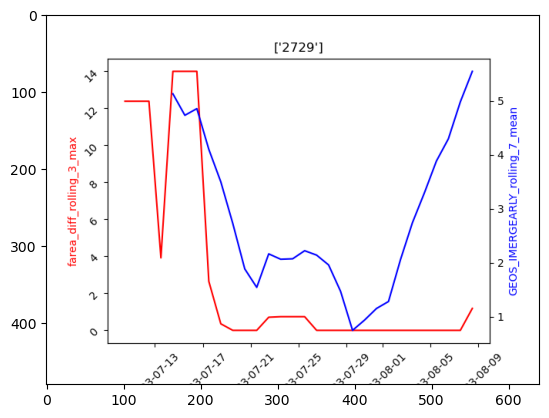

https://hub.openveda.cloud/user/mccabete/test_for_r/files/fwiVis/notebooks/exploratory_figs//home/jovyan/fwiVis/notebooks/exploratory_figs/['2729']_farea_diff_rolling_3_max_vs_GEOS_IMERGEARLY_rolling_7_mean.png?_xsrf=MnwxOjB8MTA6MTczODY3NzE4N3w1Ol94c3JmfDEzMjpZMlJtWlRobE9EbGlOVFF5TkRWaU5XRXlZVGMzTW1Vd1ltTXhaalV4WVdFNlpETmhabUkzWVdJME16VmxPVGsyWmpWaVpqRTJOek16TVRSaFkyTm1aamswWldJMk1HWXdOak5oTmpsbU5EaG1NekE1WmpJMU1HTmtaR1poWXpsbFpnPT18YTI1ODE2MjY3ZTA0ZmY1N2I5NzI3NTY3NDRkOGRhYjIzNTQyOGMxNmQ2NjhlOWRlMmViYTFiY2U4MWY2ZDBjMw


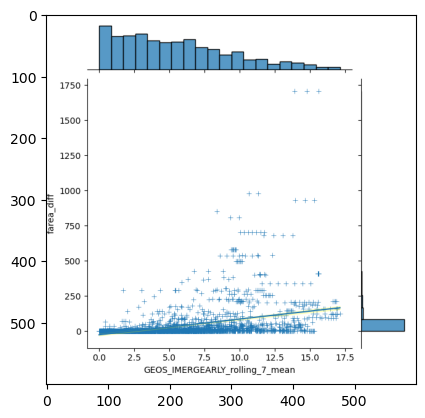

https://hub.openveda.cloud/user/mccabete/test_for_r/files/fwiVis/notebooks/exploratory_figs//farea_diff_vs_GEOS_IMERGEARLY_rolling_7_mean.png?_xsrf=MnwxOjB8MTA6MTczODY3NzE4N3w1Ol94c3JmfDEzMjpZMlJtWlRobE9EbGlOVFF5TkRWaU5XRXlZVGMzTW1Vd1ltTXhaalV4WVdFNlpETmhabUkzWVdJME16VmxPVGsyWmpWaVpqRTJOek16TVRSaFkyTm1aamswWldJMk1HWXdOak5oTmpsbU5EaG1NekE1WmpJMU1HTmtaR1poWXpsbFpnPT18YTI1ODE2MjY3ZTA0ZmY1N2I5NzI3NTY3NDRkOGRhYjIzNTQyOGMxNmQ2NjhlOWRlMmViYTFiY2U4MWY2ZDBjMw


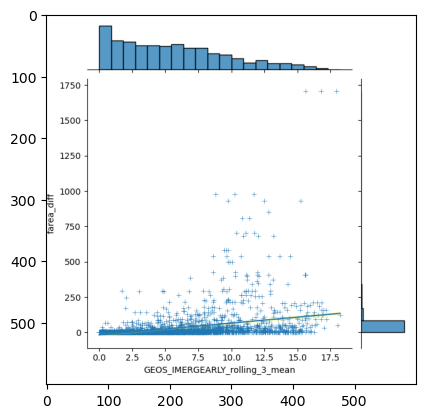

https://hub.openveda.cloud/user/mccabete/test_for_r/files/fwiVis/notebooks/exploratory_figs//farea_diff_vs_GEOS_IMERGEARLY_rolling_3_mean.png?_xsrf=MnwxOjB8MTA6MTczODY3NzE4N3w1Ol94c3JmfDEzMjpZMlJtWlRobE9EbGlOVFF5TkRWaU5XRXlZVGMzTW1Vd1ltTXhaalV4WVdFNlpETmhabUkzWVdJME16VmxPVGsyWmpWaVpqRTJOek16TVRSaFkyTm1aamswWldJMk1HWXdOak5oTmpsbU5EaG1NekE1WmpJMU1HTmtaR1poWXpsbFpnPT18YTI1ODE2MjY3ZTA0ZmY1N2I5NzI3NTY3NDRkOGRhYjIzNTQyOGMxNmQ2NjhlOWRlMmViYTFiY2U4MWY2ZDBjMw


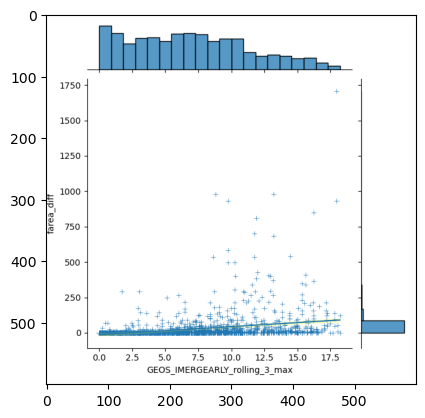

https://hub.openveda.cloud/user/mccabete/test_for_r/files/fwiVis/notebooks/exploratory_figs//farea_diff_vs_GEOS_IMERGEARLY_rolling_3_max.png?_xsrf=MnwxOjB8MTA6MTczODY3NzE4N3w1Ol94c3JmfDEzMjpZMlJtWlRobE9EbGlOVFF5TkRWaU5XRXlZVGMzTW1Vd1ltTXhaalV4WVdFNlpETmhabUkzWVdJME16VmxPVGsyWmpWaVpqRTJOek16TVRSaFkyTm1aamswWldJMk1HWXdOak5oTmpsbU5EaG1NekE1WmpJMU1HTmtaR1poWXpsbFpnPT18YTI1ODE2MjY3ZTA0ZmY1N2I5NzI3NTY3NDRkOGRhYjIzNTQyOGMxNmQ2NjhlOWRlMmViYTFiY2U4MWY2ZDBjMw


In [79]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_download_link_start = "https://hub.openveda.cloud/user/mccabete/test_for_r/files/fwiVis/notebooks/exploratory_figs/"
base_download_link_end = "?_xsrf=MnwxOjB8MTA6MTczODY3NzE4N3w1Ol94c3JmfDEzMjpZMlJtWlRobE9EbGlOVFF5TkRWaU5XRXlZVGMzTW1Vd1ltTXhaalV4WVdFNlpETmhabUkzWVdJME16VmxPVGsyWmpWaVpqRTJOek16TVRSaFkyTm1aamswWldJMk1HWXdOak5oTmpsbU5EaG1NekE1WmpJMU1HTmtaR1poWXpsbFpnPT18YTI1ODE2MjY3ZTA0ZmY1N2I5NzI3NTY3NDRkOGRhYjIzNTQyOGMxNmQ2NjhlOWRlMmViYTFiY2U4MWY2ZDBjMw"
stats_sum = pd.read_csv(f"{os.path.abspath('exploratory_stats_output')}/stats_sum_2025-02-03.csv")
print(len(stats_sum) == len(combinations))

stats_sum = stats_sum.sort_values(by = "spear", ascending= False)


print(f"The largest spearman correlation is between: {stats_sum.x.iloc[0]} and {stats_sum.y.iloc[0]} at {stats_sum.spear.iloc[0]},{stats_sum.x.iloc[1]} and {stats_sum.y.iloc[1]} at {stats_sum.spear.iloc[1]}, and {stats_sum.x.iloc[2]} and {stats_sum.y.iloc[2]} at {stats_sum.spear.iloc[2]}")

for i in [0, 1, 2]:
    
    path = f'{os.path.abspath("exploratory_figs")}/{demo_fire.fireID.unique()}_{stats_sum.y.iloc[i]}_vs_{stats_sum.x.iloc[i]}.png'
    path_sub = f'{demo_fire.fireID.unique()}_{stats_sum.y.iloc[i]}_vs_{stats_sum.x.iloc[i]}.png'
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.show()
    print(base_download_link_start + path + base_download_link_end)

for i in [0, 1, 2]:
    path = f'{os.path.abspath("exploratory_figs")}/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png'
    path_sub = f'/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png'
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.show()
    print(base_download_link_start + path_sub + base_download_link_end)

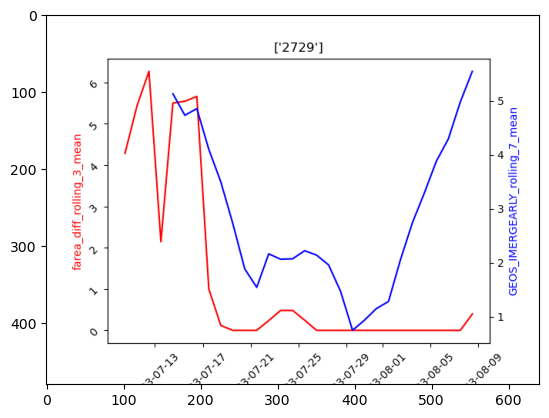

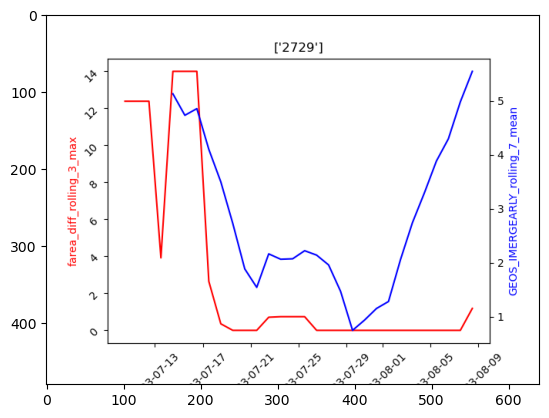

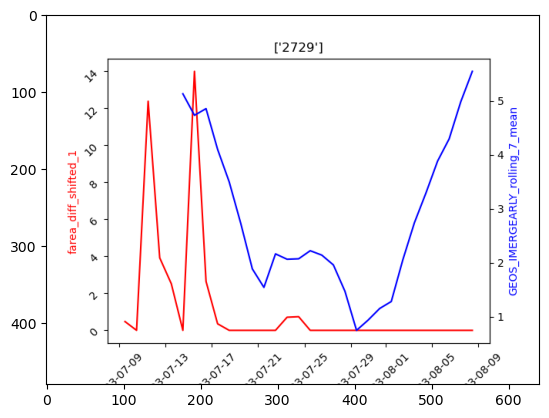

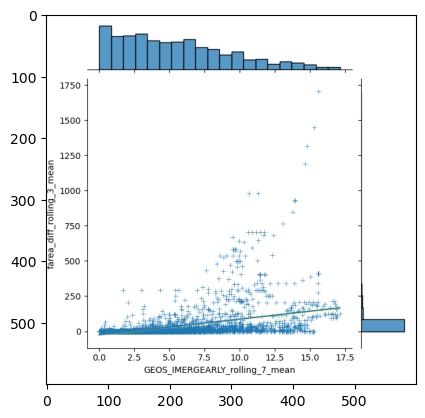

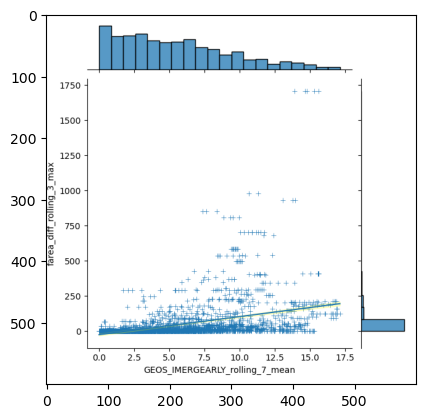

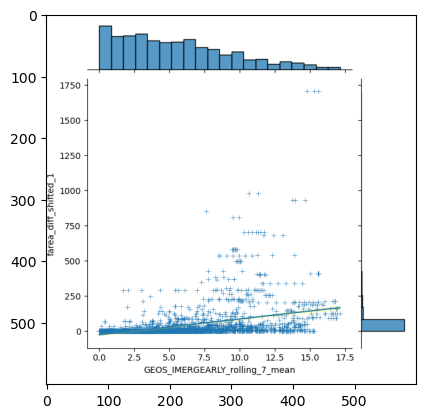

In [41]:
stats_sum_sub = stats_sum[stats_sum.x.str.contains("GEOS")]

#row_maks = 

for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{demo_fire.fireID.unique()}_{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()


for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()

## What "Tends" to improve scores? 
- shifting?
- rolling?
- mean vs max?
- 

In [ ]:
stats_sum = stats_sum.sort_values(by = "r_sq", ascending= False)
print(f"The largest R^2 (from modeled line) is between {stats_sum.x.iloc[0]} and {stats_sum.y.iloc[0]} at {stats_sum.r_sq.iloc[0]}, {stats_sum.x.iloc[1]} and {stats_sum.y.iloc[1]} at {stats_sum.r_sq.iloc[1]}, and {stats_sum.x.iloc[2]} and {stats_sum.y.iloc[2]} at {stats_sum.r_sq.iloc[2]}")

In [ ]:
stats_sum

In [ ]:
#combinations

In [ ]:
combinations = [(x, y) for x in x_rolling2 for y in y_vals2]

                 x                         y      r_sq     spear
0  GEOS_IMERGEARLY                farea_diff  0.068789  0.525794
1  GEOS_IMERGEARLY          farea_diff_stand  0.057972  0.366188
4  GEOS_IMERGEARLY         tot_ros_all_perim  0.014490  0.275053
3  GEOS_IMERGEARLY             flinelen_diff  0.017231  0.131414
2  GEOS_IMERGEARLY                  flinelen  0.029975  0.101959
5  GEOS_IMERGEARLY  tot_ros_flinelen_shifted  0.030637  0.107263


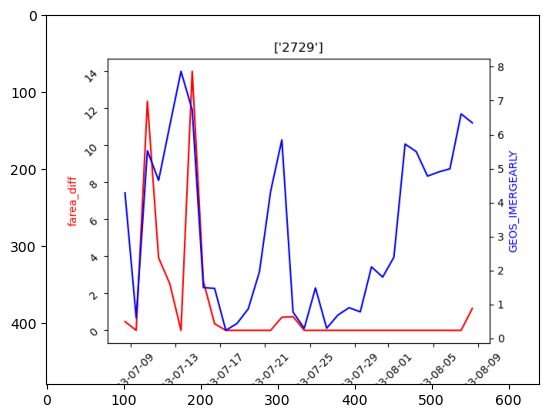

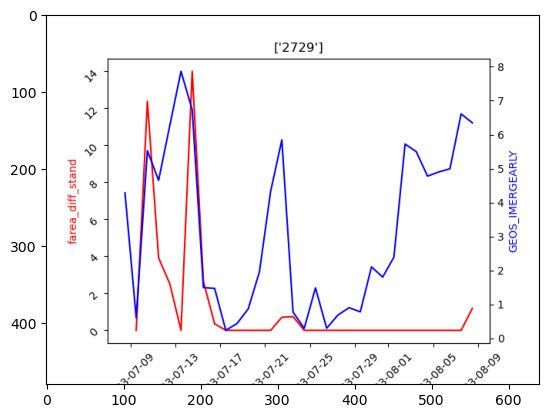

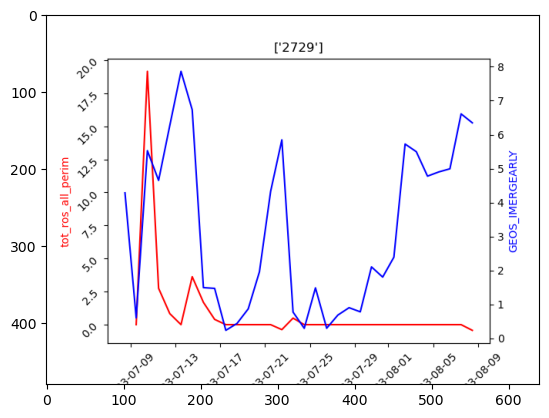

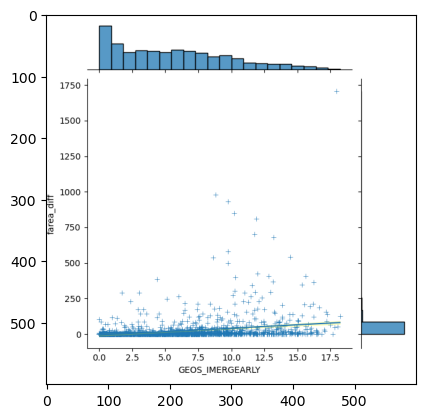

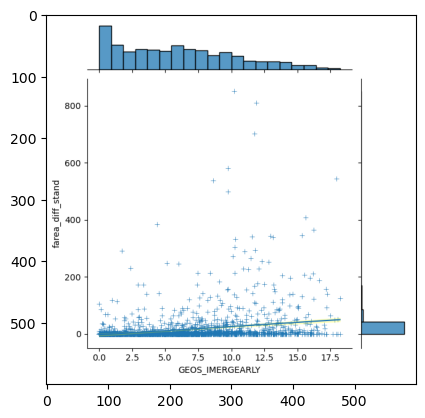

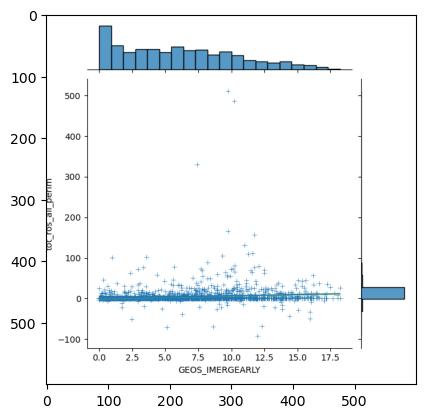

In [67]:
## Comparison 1: which "base Y" agrees best? 

row_mask = (~stats_sum.y.str.contains("shifted")) & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS")) & (~stats_sum.x.str.contains("shifted")) & (~stats_sum.x.str.contains("rolling"))

row_mask_except = stats_sum.y.str.contains("tot_ros_flinelen_shifted")  & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS")) & (~stats_sum.x.str.contains("shifted")) & (~stats_sum.x.str.contains("rolling")) & (~stats_sum.y.str.contains("shifted_"))
stats_sum_sub = stats_sum[row_mask]


stats_sum_sub = stats_sum_sub.sort_values(by = "spear", ascending= False)
stats_sum_sub = pd.concat([stats_sum_sub, stats_sum[row_mask_except]])
print(stats_sum_sub[["x", "y", "r_sq", "spear"]])

for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{demo_fire.fireID.unique()}_{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()


for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()

    

                  x                                         y      r_sq  \
43  GEOS_IMERGEARLY                farea_diff_shifted_minus_1  0.085643   
42  GEOS_IMERGEARLY                farea_diff_shifted_minus_2  0.086216   
44  GEOS_IMERGEARLY                      farea_diff_shifted_1  0.043755   
48  GEOS_IMERGEARLY          farea_diff_stand_shifted_minus_1  0.058739   
45  GEOS_IMERGEARLY                      farea_diff_shifted_2  0.038863   
49  GEOS_IMERGEARLY                farea_diff_stand_shifted_1  0.036202   
47  GEOS_IMERGEARLY          farea_diff_stand_shifted_minus_2  0.046691   
63  GEOS_IMERGEARLY         tot_ros_all_perim_shifted_minus_1  0.016839   
46  GEOS_IMERGEARLY                      farea_diff_shifted_3  0.024440   
67  GEOS_IMERGEARLY  tot_ros_flinelen_shifted_shifted_minus_2  0.077448   
64  GEOS_IMERGEARLY               tot_ros_all_perim_shifted_1  0.006320   
62  GEOS_IMERGEARLY         tot_ros_all_perim_shifted_minus_2  0.008894   
50  GEOS_IMERGEARLY      

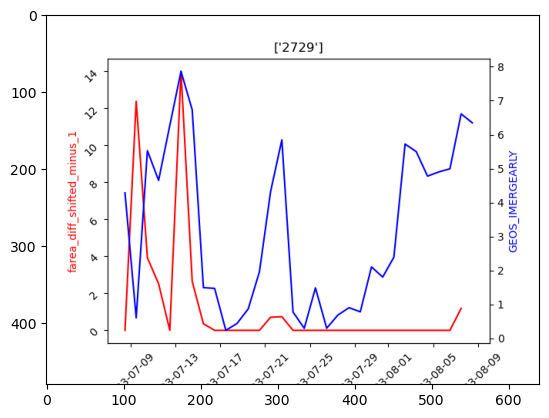

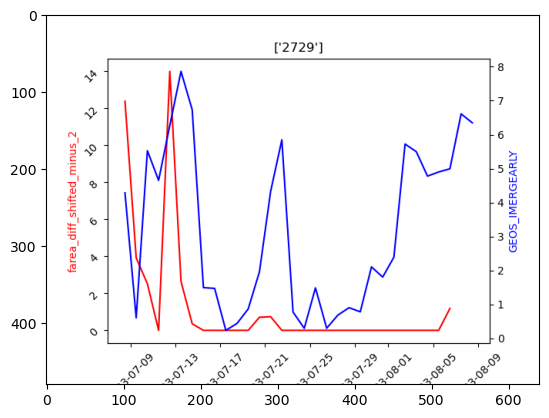

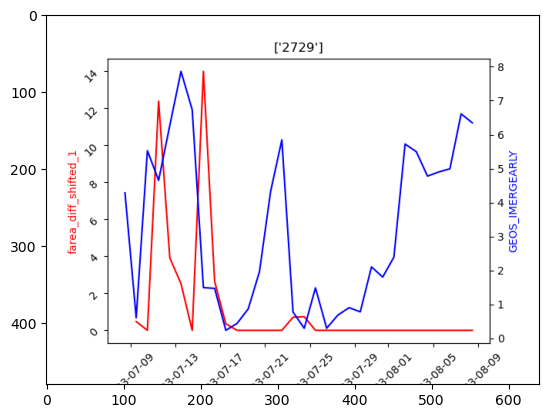

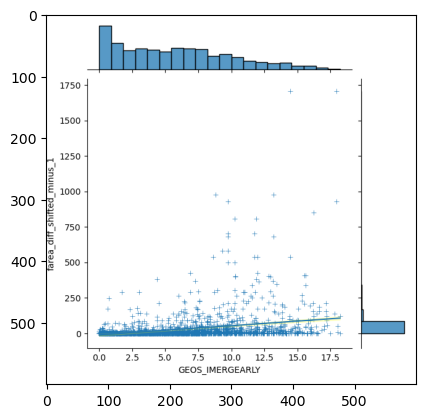

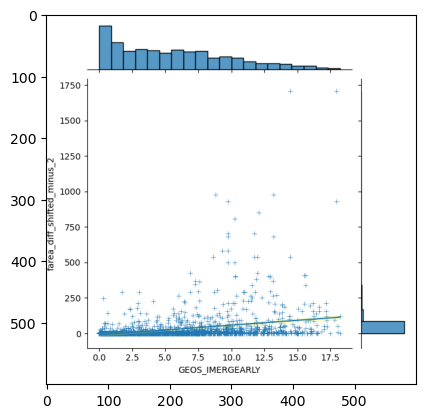

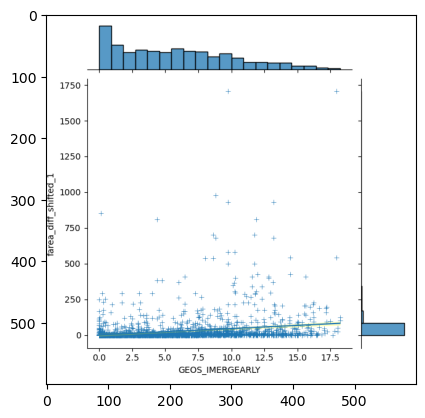

In [74]:

### Does shifting help? 

row_mask = (stats_sum.y.str.contains("shifted")) & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS"))  & (~stats_sum.x.str.contains("rolling"))

#row_mask_except = stats_sum.y.str.contains("tot_ros_flinelen_shifted")  & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS")) & (~stats_sum.x.str.contains("shifted")) & (~stats_sum.x.str.contains("rolling")) & (~stats_sum.y.str.contains("shifted_"))
stats_sum_sub = stats_sum[row_mask]


stats_sum_sub = stats_sum_sub.sort_values(by = "spear", ascending= False)
#stats_sum_sub = pd.concat([stats_sum_sub, stats_sum[row_mask_except]])
print(stats_sum_sub[["x", "y", "r_sq", "spear"]])

for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{demo_fire.fireID.unique()}_{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()


for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()

In [ ]:
### Does rolling (y) help? 

row_mask = (~stats_sum.y.str.contains("shifted")) & (stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS"))  & (~stats_sum.x.str.contains("rolling")) & (~stats_sum.x.str.contains("shifted"))

#row_mask_except = stats_sum.y.str.contains("tot_ros_flinelen_shifted")  & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS")) & (~stats_sum.x.str.contains("shifted")) & (~stats_sum.x.str.contains("rolling")) & (~stats_sum.y.str.contains("shifted_"))
stats_sum_sub = stats_sum[row_mask]


stats_sum_sub = stats_sum_sub.sort_values(by = "spear", ascending= False)
#stats_sum_sub = pd.concat([stats_sum_sub, stats_sum[row_mask_except]])
print(stats_sum_sub[["x", "y", "r_sq", "spear"]])

for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{demo_fire.fireID.unique()}_{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()


for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()

                                        x                  y      r_sq  \
576        GEOS_IMERGEARLY_rolling_7_mean         farea_diff  0.150609   
144        GEOS_IMERGEARLY_rolling_3_mean         farea_diff  0.109730   
216         GEOS_IMERGEARLY_rolling_3_max         farea_diff  0.074857   
648         GEOS_IMERGEARLY_rolling_7_max         farea_diff  0.066780   
217         GEOS_IMERGEARLY_rolling_3_max   farea_diff_stand  0.077429   
649         GEOS_IMERGEARLY_rolling_7_max   farea_diff_stand  0.066673   
145        GEOS_IMERGEARLY_rolling_3_mean   farea_diff_stand  0.054194   
220         GEOS_IMERGEARLY_rolling_3_max  tot_ros_all_perim  0.021834   
652         GEOS_IMERGEARLY_rolling_7_max  tot_ros_all_perim  0.013892   
148        GEOS_IMERGEARLY_rolling_3_mean  tot_ros_all_perim  0.014095   
577        GEOS_IMERGEARLY_rolling_7_mean   farea_diff_stand  0.035432   
721  GEOS_IMERGEARLY_rolling_7_line_trend   farea_diff_stand  0.013506   
720  GEOS_IMERGEARLY_rolling_7_line_tr

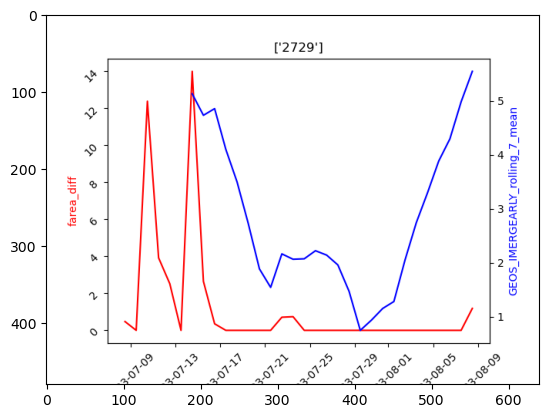

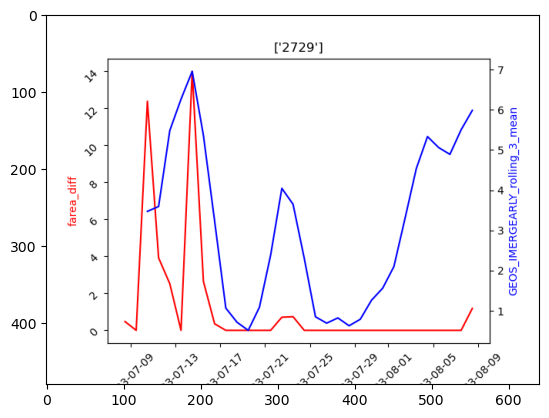

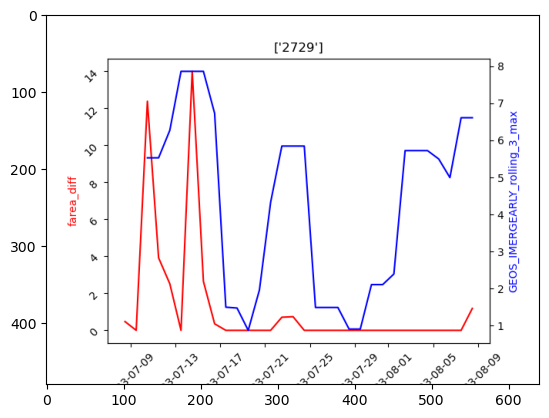

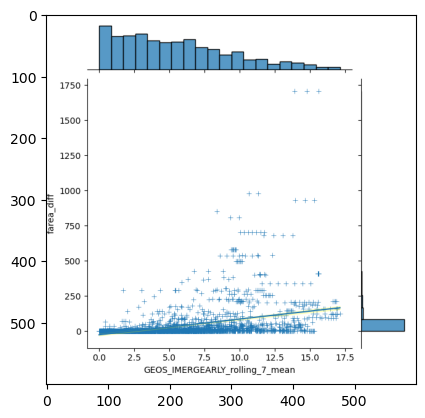

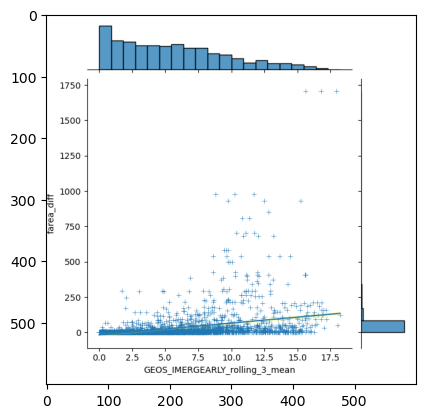

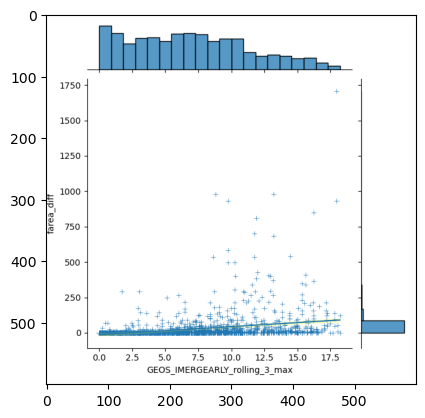

In [76]:
### Does rolling (x) help? 

row_mask = (~stats_sum.y.str.contains("shifted")) & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS"))  & (stats_sum.x.str.contains("rolling")) & (~stats_sum.x.str.contains("shifted"))

#row_mask_except = stats_sum.y.str.contains("tot_ros_flinelen_shifted")  & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS")) & (~stats_sum.x.str.contains("shifted")) & (~stats_sum.x.str.contains("rolling")) & (~stats_sum.y.str.contains("shifted_"))
stats_sum_sub = stats_sum[row_mask]


stats_sum_sub = stats_sum_sub.sort_values(by = "spear", ascending= False)
#stats_sum_sub = pd.concat([stats_sum_sub, stats_sum[row_mask_except]])
print(stats_sum_sub[["x", "y", "r_sq", "spear"]])

for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{demo_fire.fireID.unique()}_{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()


for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()

In [ ]:
### Does rolling (y) help? 

row_mask = (~stats_sum.y.str.contains("shifted")) & (stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS"))  & (~stats_sum.x.str.contains("rolling")) & (~stats_sum.x.str.contains("shifted"))

#row_mask_except = stats_sum.y.str.contains("tot_ros_flinelen_shifted")  & (~stats_sum.y.str.contains("rolling")) & (stats_sum.x.str.contains("GEOS")) & (~stats_sum.x.str.contains("shifted")) & (~stats_sum.x.str.contains("rolling")) & (~stats_sum.y.str.contains("shifted_"))
stats_sum_sub = stats_sum[row_mask]


stats_sum_sub = stats_sum_sub.sort_values(by = "spear", ascending= False)
#stats_sum_sub = pd.concat([stats_sum_sub, stats_sum[row_mask_except]])
print(stats_sum_sub[["x", "y", "r_sq", "spear"]])

for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{demo_fire.fireID.unique()}_{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()


for i in [0, 1, 2]:
    img = mpimg.imread(f'{os.path.abspath("exploratory_figs")}/{stats_sum_sub.y.iloc[i]}_vs_{stats_sum_sub.x.iloc[i]}.png')
    plt.imshow(img)
    plt.show()